<a href="https://colab.research.google.com/github/kingdragonlord/bert-self-attention-mechanisms/blob/main/bert_self_attention_mechanisms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basics of Self Attention

Suppose we are given an input sequence of vectors $x_1, \ldots, x_n$. The goal of self attention is compute context vectors $z_i$ for each input sequence element $x_i$. The context vector $z_i$ is a weighted sum over all of the inputs $x_1, \ldots, x_n$.

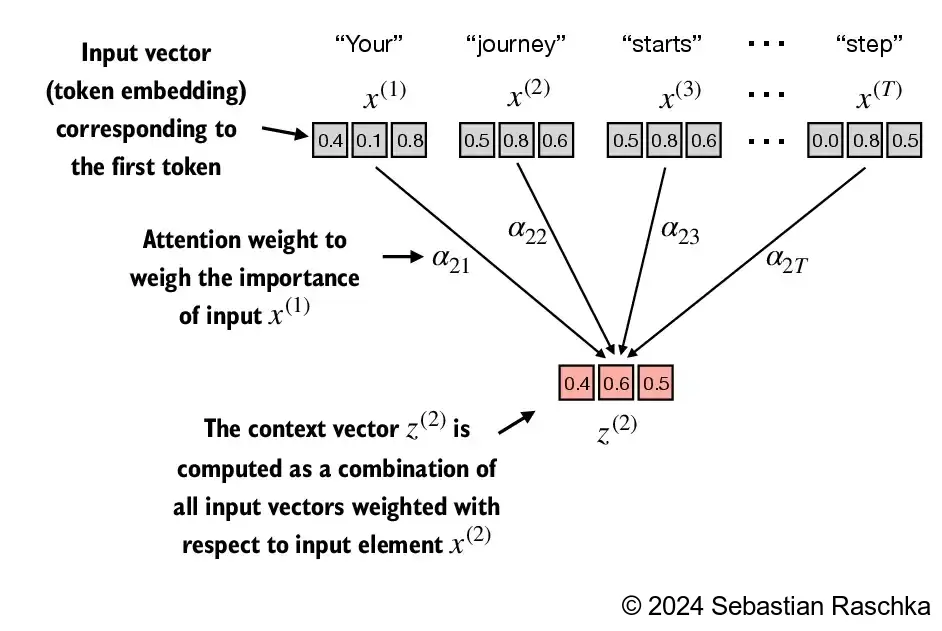

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

text = "The mystery of life isn't a problem to solve, but a reality to experience."
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

First, let's examine how this tokenizer broke down our input sentence:

In [ ]:
print(tokenizer.tokenize(text))

['the', 'mystery', 'of', 'life', 'isn', "'", 't', 'a', 'problem', 'to', 'solve', ',', 'but', 'a', 'reality', 'to', 'experience', '.']


And now for the token ids:

In [ ]:
token_ids = tokenizer(text, return_tensors='pt', add_special_tokens=False)['input_ids'][0]
token_ids

tensor([1996, 6547, 1997, 2166, 3475, 1005, 1056, 1037, 3291, 2000, 9611, 1010,
        2021, 1037, 4507, 2000, 3325, 1012])

In [ ]:
tokenizer.decode(token_ids)

"the mystery of life isn ' t a problem to solve, but a reality to experience."

# Task: Attention Mechanism for BERT-like Models

In models like BERT, we follow the same steps for the attention mechanism except we remove the causal masking we were required to use for autoregressive language modeling. This means that our representations can include weighted combinations of token information from any point in the sequence. Let's go through the step by step process of computing the attention scores and context vectors for the word "mystery" in the sentence above for this style of attention.

First, we can use the embedding layers of the BERT model in order to extract embeddings for our text data:

In [ ]:
inputs = tokenizer(text, return_tensors='pt', add_special_tokens=False)
inputs

{'input_ids': tensor([[1996, 6547, 1997, 2166, 3475, 1005, 1056, 1037, 3291, 2000, 9611, 1010,
         2021, 1037, 4507, 2000, 3325, 1012]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [ ]:
X = model.embeddings(inputs['input_ids']).data.squeeze()
X.shape

torch.Size([18, 768])

`X` contains the embeddings for our text data, we have one row for each token in the sequence, and each token is now represented as a `768` dimensional embedding.

In [ ]:
X

tensor([[-1.8851e-01,  1.9955e-02, -2.1439e-01,  ..., -3.2344e-01,
          1.1769e-01, -1.0134e-01],
        [ 2.5285e-01, -4.4110e-01,  7.8309e-01,  ...,  2.3928e-01,
         -4.2789e-01, -4.5822e-01],
        [-6.8597e-01,  4.3987e-01,  2.0507e-01,  ...,  4.8811e-01,
          3.5669e-01,  2.9921e-01],
        ...,
        [ 2.0238e-01,  8.0363e-01,  1.0896e-01,  ...,  7.2119e-01,
         -1.0717e-01,  5.6905e-01],
        [-9.4312e-01,  7.2408e-01, -7.7016e-01,  ...,  2.0627e-01,
         -1.5650e-01, -6.8972e-01],
        [-3.5590e-01,  4.5001e-01, -2.1169e-04,  ...,  7.4230e-01,
          1.7072e-01,  4.7457e-01]])

Next, form a query vector for the word "mystery".

In [ ]:
# Get the index of "mystery"
mystery_index = tokenizer.convert_tokens_to_ids(tokenizer.tokenize(text))[1]

# Get the embedding for "mystery"
mystery_embedding = X[1]

# Form a query vector for "mystery"
query_vector = model.embeddings(inputs['input_ids']).data.squeeze()[1]

# Linear layer for query
query_linear = nn.Linear(768, 64, bias=False) # Assuming the query/key/value dimension is 64

query = query_linear(query_vector)

print(query)

tensor([ 0.1120,  0.4457, -0.2137,  0.0916, -0.1750,  0.1183,  0.4769,  0.4997,
         0.3336, -0.1708,  0.6345,  0.0923, -0.6997, -0.0228,  0.4717, -0.1579,
         0.4948,  0.1383,  0.1740,  0.3463,  0.0426, -0.2908,  0.2617, -0.2720,
        -0.3835,  0.4375,  0.7282,  0.1401,  0.7887,  0.0673,  0.6284,  0.0673,
         0.4817,  0.0532,  0.0539,  0.0218,  0.0619,  0.5795, -0.6260,  0.6392,
         0.0721,  0.1197,  0.4096, -0.2980, -0.4067,  0.0241, -0.5076,  0.0027,
         0.0409,  0.1164, -0.0526, -0.1351, -0.5268,  0.3461, -0.1203,  0.2420,
         0.4926,  0.2103, -0.2374,  0.3158, -0.2731, -0.4323,  0.0769, -0.1463],
       grad_fn=<SqueezeBackward4>)


Now, compute the unnormalized attention scores via dot products of this query vector with the key vectors for all words in the sequence.

In [ ]:
# Get the key vectors for all words
key_linear = nn.Linear(768, 64, bias=False) # Assuming the query/key/value dimension is 64
keys = key_linear(X)

# Compute the unnormalized attention scores
attention_scores = torch.matmul(query, keys.T)

print(attention_scores)

tensor([-1.3726, -0.0048, -1.2608, -0.8138,  1.6354,  1.1262,  1.0652, -0.2640,
        -0.0213, -0.1887,  0.1189, -0.3048,  0.7962,  0.3382, -0.5871,  0.1395,
         1.6356, -0.4834], grad_fn=<SqueezeBackward4>)


In order to get the normalized attention weights, we use softmax. Normalize your attention scores to get a set of attention weights:

In [ ]:
# Normalize the attention scores
attention_weights = torch.nn.functional.softmax(attention_scores, dim=-1)

print(attention_weights)

tensor([0.0089, 0.0348, 0.0099, 0.0155, 0.1794, 0.1078, 0.1014, 0.0268, 0.0342,
        0.0289, 0.0394, 0.0258, 0.0775, 0.0490, 0.0194, 0.0402, 0.1794, 0.0216],
       grad_fn=<SoftmaxBackward0>)


Plot the unnormalized and normalized attention weights for this vector.

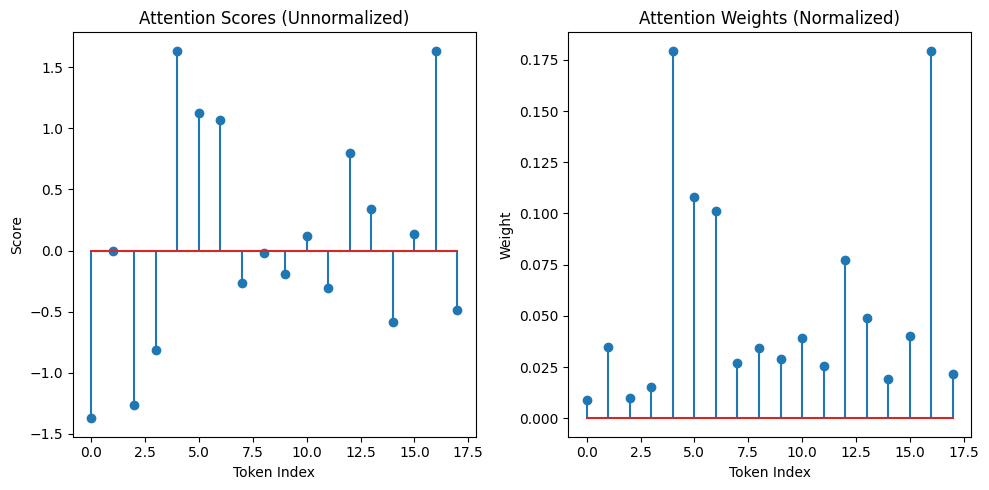

In [ ]:
import matplotlib.pyplot as plt

# Plot the unnormalized and normalized attention weights
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(range(len(attention_scores)), attention_scores.detach().numpy())
plt.title('Attention Scores (Unnormalized)')
plt.xlabel('Token Index')
plt.ylabel('Score')

plt.subplot(1, 2, 2)
plt.stem(range(len(attention_weights)), attention_weights.detach().numpy())
plt.title('Attention Weights (Normalized)')
plt.xlabel('Token Index')
plt.ylabel('Weight')

plt.tight_layout()
plt.show()


The outputs of the attention layer are enriched context vector $z_i$ corresponding to the word $x_i$, computed by taking a weighted sum of the values $v_1, \ldots, v_n$ using the attention weights. Form a set of value vectors from your data, then use the attention weights you computed above to compute the output vector for "mystery".

In [ ]:
# Get the value vectors for all words
value_linear = nn.Linear(768, 64, bias=False) # Assuming the query/key/value dimension is 64
values = value_linear(X)

# Compute the output vector for "mystery"
output_vector = torch.matmul(attention_weights, values)

print(output_vector)
print(output_vector.shape)


tensor([ 0.0280,  0.1022, -0.1114, -0.0316, -0.0925, -0.1938, -0.1962, -0.2073,
         0.0421,  0.0694, -0.0997,  0.1028, -0.0359, -0.1097,  0.0311,  0.0910,
         0.0341, -0.0065, -0.1769, -0.1292, -0.0374, -0.0072,  0.0529, -0.0894,
        -0.1610, -0.1321,  0.0499, -0.1235,  0.0300,  0.0342, -0.0550,  0.0830,
        -0.0128, -0.2584,  0.1629,  0.0111,  0.0373,  0.1736,  0.0902, -0.1821,
         0.2025, -0.0452, -0.0304, -0.1953,  0.0655,  0.0161, -0.3209, -0.1224,
        -0.0414, -0.0102, -0.1670,  0.1463,  0.0639, -0.0321,  0.1230,  0.0680,
        -0.0888,  0.1299,  0.0785,  0.2129, -0.2139, -0.1772,  0.2375,  0.0643],
       grad_fn=<SqueezeBackward4>)
torch.Size([64])


Everything we've done so far is looking at a single head of attention for a single token flowing through the attention layer. Our output for this token has shape $d_V$ <= $d$ where $d$ is the size of our embedding, often referred to as the "model dimension". How many heads in this attention layer would we need to stack in order to get a concatenated output of shape $d$?

In [ ]:
# Determine the number of heads needed
d = 768
dV = 64
num_heads = d // dV

print(f'Number of heads needed: {num_heads}')


Number of heads needed: 12
